In [1]:
from qiskit.circuit import Parameter, QuantumCircuit, QuantumRegister, ClassicalRegister

from qiskit.quantum_info import Pauli, SparsePauliOp, Statevector, Operator
from scipy.optimize import minimize 
from qiskit.circuit.library import QFT
from qiskit import transpile
from qiskit.circuit.library import UnitaryGate

import random
import matplotlib.pyplot as plt
import scipy.linalg as scl
import numpy as np
from qiskit_aer import AerSimulator
from qiskit_ibm_runtime.fake_provider import FakeFez
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

# backend = AerSimulator()

backend=FakeFez()
# sampler = Sampler(backend = backend)
pm = generate_preset_pass_manager(backend=backend,optimization_level=2)

In [2]:


nb_qubits = 3

N = 2**nb_qubits
m = np.zeros((N,N))
for j in range(N):
    if j == N-1:
        break
    else:
       m[j,j+1] = -1 

for j in range(N):
    if j == N-1:
        break
    else:
       m[j+1,j] = -1 
for j in range(N):
   m[j,j] = 2 
m[0] = np.array([1]+ [0]*(N-1))
m[1,0] = 0

b = np.array([0,0.25,0.25,0.25,0.25,0.5,0.5,0.5])
m

array([[ 1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
       [ 0.,  2., -1.,  0.,  0.,  0.,  0.,  0.],
       [ 0., -1.,  2., -1.,  0.,  0.,  0.,  0.],
       [ 0.,  0., -1.,  2., -1.,  0.,  0.,  0.],
       [ 0.,  0.,  0., -1.,  2., -1.,  0.,  0.],
       [ 0.,  0.,  0.,  0., -1.,  2., -1.,  0.],
       [ 0.,  0.,  0.,  0.,  0., -1.,  2., -1.],
       [ 0.,  0.,  0.,  0.,  0.,  0., -1.,  2.]])

In [3]:
d,u = np.linalg.eig(m)
k = np.max(d)/np.min(d)
dm = max(d)
# m = m/dm

In [4]:
np.linalg.det(m)



7.999999999999998

In [5]:
def U_b(nb_qubits):
    circ = QuantumCircuit(nb_qubits)
    circ.prepare_state(b)
    return circ
U = U_b(nb_qubits)
b = np.array(Statevector(U_b(nb_qubits)))
b

array([1.80411242e-16+6.93889390e-17j, 2.50000000e-01+5.13478149e-16j,
       2.50000000e-01-2.98372438e-16j, 2.50000000e-01-3.33066907e-16j,
       2.50000000e-01-6.66133815e-16j, 5.00000000e-01-6.10622664e-16j,
       5.00000000e-01+6.80011603e-16j, 5.00000000e-01+7.21644966e-16j])

In [6]:
def Hamiltonian(m):
    Ub = np.array(Operator(U_b(nb_qubits)))
    z = np.array([[1,0],
                 [0,-1]])
    I = np.array([[1,0],
                 [0,1]])
    def tensor(j,k,l):
        return np.kron(j,np.kron(k,l))
    M1 = (np.dot(np.dot(Ub,tensor(z,I,I)),np.conj(Ub.T))
          + np.dot(np.dot(Ub,tensor(I,z,I)),np.conj(Ub.T))
          +np.dot(np.dot(Ub,tensor(I,I,z)),np.conj(Ub.T)))
    M = 0.5*np.dot(np.dot(np.conj(m.T),(tensor(I,I,I) - M1/nb_qubits)),m)

    return M
A = Hamiltonian(m)

In [7]:
U1=scl.expm(2**0*2*np.pi*1j*A) 
U2=scl.expm(2**1*2*np.pi*1j*A) 
U3=scl.expm(2**2*2*np.pi*1j*A) 
U4=scl.expm(2**3*2*np.pi*1j*A) 
U5=scl.expm(2**4*2*np.pi*1j*A) 
U6=scl.expm(2**5*2*np.pi*1j*A) 
U7=scl.expm(2**6*2*np.pi*1j*A) 
U8=scl.expm(2**7*2*np.pi*1j*A)
 
u1gate = UnitaryGate(U1)
u2gate = UnitaryGate(U2)
u3gate=UnitaryGate(U3)
u4gate=UnitaryGate(U4)
u5gate=UnitaryGate(U5)
u6gate=UnitaryGate(U6)
u7gate=UnitaryGate(U7)
u8gate=UnitaryGate(U8)


C_u1gate=u1gate.control()
C_u2gate=u2gate.control()
C_u3gate=u3gate.control()
C_u4gate=u4gate.control()
C_u5gate=u5gate.control()
C_u6gate=u6gate.control()
C_u7gate=u7gate.control()
C_u8gate=u8gate.control()

In [5]:
x_exact = np.linalg.solve(m,b)
x_exact = x_exact/np.linalg.norm(x_exact)
nb_qubits = 3
depth = 2
qubits = list(range(nb_qubits))
N = len(qubits)
nb_params = int(9*N*depth)
RMSE = []
# rep = 10
# for _ in range(rep):

Parameters = np.array([random.random() for _ in range(0, nb_params)])
def ansatz(Parameters):
    qc = QuantumCircuit(N)
    for d in range(depth):
        param1=Parameters[d*9*N:(d+1)*(9*N)]
        for q in range(N):
            qc.ry(param1[q],qubits[q])
            qc.ry(param1[q+N],qubits[q])
            qc.ry(param1[q+2*N],qubits[q])
        qc.barrier()
        for q in range(N):
            qc.cx(qubits[q], qubits[(q+1)% N])
            qc.ry(param1[q+3*N],qubits[q])
            qc.ry(param1[q+4*N],qubits[(q+1)% N])
            qc.cx(qubits[(q+1)% N], qubits[q])
            qc.ry(param1[q+5*N],qubits[(q+1)% N])
            qc.cx(qubits[q], qubits[(q+1)% N])
        qc.barrier()
        if d==depth-1:
            for q in range(N):
                qc.ry(param1[q+6*N],qubits[q])
                qc.ry(param1[q+7*N],qubits[q])
                qc.ry(param1[q+8*N],qubits[q])
        qc.barrier()
    
    return qc    
Parameters

array([0.06082846, 0.76076142, 0.72227033, 0.237717  , 0.81679031,
       0.56919258, 0.50519165, 0.25236684, 0.1518571 , 0.15560034,
       0.09808309, 0.76156652, 0.87808497, 0.85204985, 0.12658519,
       0.07999036, 0.95267938, 0.80287467, 0.72530144, 0.65756308,
       0.2210422 , 0.30755194, 0.06534449, 0.24531727, 0.48755635,
       0.51823803, 0.20959943, 0.30937504, 0.91818385, 0.16883663,
       0.28920406, 0.3890972 , 0.71463243, 0.46659455, 0.05898153,
       0.30170061, 0.61244542, 0.6734508 , 0.60983154, 0.98056684,
       0.71947963, 0.1050776 , 0.47711788, 0.56723587, 0.51076938,
       0.13967961, 0.63737258, 0.16478647, 0.3566552 , 0.4012373 ,
       0.36668087, 0.97130287, 0.56954166, 0.2260593 ])

In [9]:
   
    
def circ(parameters):
    x=QuantumRegister(11)
    c=ClassicalRegister(8)
    circuit = QuantumCircuit(x,c)
    phi=parameters
    circuit=circuit.compose(ansatz(parameters),x[8:11])
    circuit.h(x[0:8]) 
    circuit.append(C_u1gate, [x[0],x[8],x[9],x[10]])    
    circuit.append(C_u2gate, [x[1],x[8],x[9],x[10]])    
    circuit.append(C_u3gate, [x[2],x[8],x[9],x[10]])    
    circuit.append(C_u4gate, [x[3],x[8],x[9],x[10]]) 
    circuit.append(C_u5gate, [x[4],x[8],x[9],x[10]])
    circuit.append(C_u6gate, [x[5],x[8],x[9],x[10]])    
    circuit.append(C_u7gate, [x[6],x[8],x[9],x[10]]) 
    circuit.append(C_u8gate, [x[7],x[8],x[9],x[10]])
    circuit &= QFT(num_qubits = 8, approximation_degree = 0, do_swaps = True, 
                   inverse = True, insert_barriers = False, name='qft')
    circuit.measure(x[0:8],c)       
    return circuit

In [10]:
    
shots = 100000
def cost(Parameters):
    job = backend.run(pm.run(circ(Parameters)),shots = shots).result()
    result = job.get_counts(0)
    if '00000000'not in result: 
        res = 1
    else:
        res = 1 - result['00000000']/shots
    return res
# cost(parameters)

In [11]:
def Optimizer(fun, x0, args=(), maxfev=None, 
              reset_interval=None, eps=None, callback=None, **_):
    
    x0 = np.asarray(x0)
    recycle_z0 = None
    niter = 0
    funcalls = 0
    
    while True:

        idx = niter % x0.size

        if reset_interval > 0:
            if niter % reset_interval == 0:
                recycle_z0 = None

        if recycle_z0 is None:
            z0 = fun(np.copy(x0), *args)
            funcalls += 1
        else:
            z0 = recycle_z0

        p = np.copy(x0)
        p[idx] = x0[idx] + np.pi / 2
        z1 = fun(p, *args)
        funcalls += 1

        p = np.copy(x0)
        p[idx] = x0[idx] - np.pi / 2
        z3 = fun(p, *args)
        funcalls += 1

        z2 = z1 + z3 - z0
        c = (z1 + z3) / 2
        a = np.sqrt((z0 - z2) ** 2 + (z1 - z3) ** 2) / 2
        b = np.arctan((z1 - z3) / ((z0 - z2) + 1e-32 * (z0 == z2))) + x0[idx]
        b += 0.5 * np.pi + 0.5 * np.pi * np.sign((z0 - z2) + eps * (z0 == z2))
        x0[idx] = b
        recycle_z0 = c - a
        if callback is not None:
            callback(np.copy(x0))
        if funcalls >= maxfev:
            break
        niter += 1
    # return OptimizeResult(fun=problabel0(np.copy(x0)), x=x0, nit=niter, 
    #                       nfev=funcalls, success=(niter > 1))
  

In [ ]:
def save(Parameters):
    global Cost,Params
    Cost.append(cost(Parameters))
    Params.append(Parameters)
    # print(cost(Parameters))
Cost = []
Params = []
Optimizer(cost, Parameters, args=(), maxfev = 4000, 
          reset_interval = 32, eps=1e-32, callback=save)


In [15]:
e = []
F = []
norm_e = []
for k in range(len(Params)):
    state = np.array(Statevector(ansatz(Params[k])))
    norm = np.dot(state,x_exact)
    e.append(x_exact - state/norm)
    f = abs(np.dot(state,x_exact))**2
    F.append(f)

for v in e:
    norm_e.append(float(np.linalg.norm(v)))
Res = norm_e[np.argmax(F)]
print(Res)
# RMSE.append(Res)

0.09029676906693748


In [14]:
print(Cost)

[0.99337, 0.99378, 0.99289, 0.99308, 0.99332, 0.99251, 0.99343, 0.99227, 0.9929, 0.9927, 0.99328, 0.99142, 0.99184, 0.98946, 0.98902, 0.99213, 0.99171, 0.99198, 0.99112, 0.9914, 0.99244, 0.99074, 0.99155, 0.9925, 0.99257, 0.9919, 0.99227, 0.99122, 0.99141, 0.99185, 0.99081, 0.99241, 0.99219, 0.993, 0.99444, 0.99496, 0.99425, 0.99484, 0.99359, 0.99466, 0.99522, 0.99476, 0.99488, 0.99481, 0.99465, 0.99433, 0.99452, 0.99425, 0.99406, 0.994, 0.99418, 0.99389, 0.99429, 0.99363, 0.99385, 0.99332, 0.99213, 0.99347, 0.99322, 0.99101, 0.99297, 0.99331, 0.99372, 0.99247, 0.99469, 0.99493, 0.9947, 0.9945, 0.99485, 0.99405, 0.99433, 0.99429, 0.99412, 0.99381, 0.9938, 0.99452, 0.99422, 0.99439, 0.9939, 0.99382, 0.99381, 0.99417, 0.99361, 0.9935, 0.99369, 0.99247, 0.99369, 0.99276, 0.99305, 0.99236, 0.99181, 0.99354, 0.99163, 0.99262, 0.99238, 0.9924, 0.99235, 0.99181, 0.99175, 0.99258, 0.99154, 0.99235, 0.992, 0.9924, 0.99202, 0.99295, 0.99209, 0.99192, 0.99072, 0.99175, 0.98978, 0.99238, 0.99243, 

In [16]:
print(F)

[0.0383524245610894, 0.14844929258665804, 0.31937680899920423, 0.43522206211945197, 0.5701588393604934, 0.5902981018568366, 0.5936402514672791, 0.6305031804327298, 0.6261125207494044, 0.6560853918951286, 0.6314186371807627, 0.9162061655873762, 0.9274143424513833, 0.9300315711189572, 0.928179230465242, 0.9331465757305147, 0.9344553953132209, 0.9367525906898546, 0.9367525906898546, 0.9367525906898546, 0.9367525906898546, 0.9367525906898546, 0.9367525906898546, 0.9367525906898546, 0.9367525906898546, 0.9367525906898546, 0.9367525906898546, 0.9480903715040598, 0.9388896135073758, 0.9441109233497963, 0.9423770141805843, 0.9409018041516213, 0.9039605218764315, 0.8510871552268573, 0.05050521495341237, 0.05099003980148811, 0.05131375309070817, 0.03619882613511908, 0.03690001305589806, 0.03579674641885071, 0.04101337948925687, 0.04102938582170721, 0.03231206816070223, 0.03762479738688762, 0.08160658160687491, 0.125324849549642, 0.1304541716505424, 0.1480148662629531, 0.19518778824347668, 0.2053

In [29]:
print(norm_e)

[5.007391621308263, 2.3950588595572606, 1.4598279777989736, 1.1391565470549858, 0.8682725460301607, 0.8331022255743952, 0.8273583822782, 0.7655291129126279, 0.772759346434939, 0.7240109384388903, 0.7640257352359031, 0.30241924658152086, 0.2797618580709489, 0.27428509952247604, 0.2781692400250979, 0.2676621087142207, 0.2648434193216974, 0.2598417419703475, 0.2598417419703475, 0.2598417419703475, 0.2598417419703475, 0.2598417419703475, 0.2598417419703475, 0.2598417419703475, 0.2598417419703475, 0.2598417419703475, 0.2598417419703475, 0.2339909670799129, 0.2551233728604327, 0.24330551663440247, 0.24727803263647016, 0.25061955863985513, 0.32594938324856493, 0.4182915217853647, 4.335889243266498, 4.3141248542451445, 4.299761950926864, 5.159961744092987, 5.1088414943252625, 5.189942170416897, 4.835523472683045, 4.8345398196309235, 5.472493877076525, 5.05749109887031, 3.354685320193951, 2.6418295779091743, 2.581768229577535, 2.399182803392669, 2.030583988091918, 1.9671385400935542, 1.70147585

In [25]:
opt_params = Params[np.argmax(F)]
opt_params

array([ 3.02911074,  0.22831644, -0.29843462,  1.29767278,  6.4989752 ,
        0.28780829, -0.32823398,  5.43082847,  0.89434083, -1.86140866,
        3.0708449 , -1.03460314,  1.70374008,  1.21586712,  0.70325377,
       -0.90790324, -0.53977699, -0.43430873,  3.80694745, 10.95432892,
        6.78582478,  3.74085837,  1.70438821, -0.38575749, -0.99575879,
        0.63968015, -1.76010131,  0.09174279,  1.66505976,  0.14260046,
       -0.32909496,  0.21815069, -0.5639741 ,  0.25461121,  3.70087627,
        1.52167968, -0.73123678,  0.13092403,  1.38515671,  0.37058389,
       -1.08525693, -0.04037335, -0.62466833,  0.96012843,  0.16793995,
        1.23010009,  2.47254446, -1.02036692,  0.4847116 , -0.98793604,
        1.91649096,  1.58130067, -0.13740354,  0.71045722])

In [8]:
X_opt = np.array(Statevector(ansatz(opt_params)))
X_opt = np.array([-0.03311519+0.j, -0.16066311+0.j, -0.29797099+0.j, -0.42306105+0.j,
       -0.49169522+0.j, -0.53247058+0.j, -0.35359881+0.j, -0.23452539+0.j])

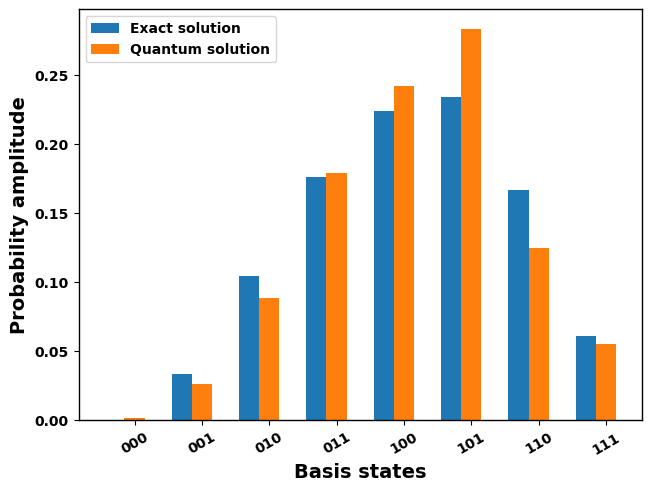

In [25]:
states = ('000', '001','010','011','100', '101','110','111')
Solutions = {
    'Exact solution': np.round(abs(x_exact)**2,6),
    'Quantum solution': np.round(abs(X_opt)**2,6),
}

x = np.arange(len(states))  # the label locations
width = 0.3  # the width of the bars
multiplier = 0

fig, ax3 = plt.subplots(layout = 'constrained')

plt.rc('axes', linewidth = 1)
legend_properties = {'weight':'bold'}

for attribute, measurement in Solutions.items():
    offset = width * multiplier
    rects = ax3.bar(x + offset, measurement, width,label = attribute)
    # ax3.bar_label(rects, padding=2)
    multiplier += 1

plt.xlabel('Basis states',fontsize = 14,weight='bold')
plt.ylabel('Probability amplitude',fontsize=14,weight='bold')

legend = plt.legend(fontsize = 20,prop = legend_properties)

ax3.set_xticks(x + width, states,rotation = 30)
# ax3.legend(loc='upper left', ncols = 2)

ax3 = plt.gca()
for tick in ax3.get_xticklabels():
	tick.set_fontweight('bold')
for tick in ax3.get_yticklabels():
	tick.set_fontweight('bold')
plt.savefig('fig8b.pdf')
